
![alt text](screenshots/image-19.png)

<!-- ![alt text](screenshots/image-20.png)
 
![alt text](screenshots/image-22.png) -->
 

# **Business Understanding:**

Objective of finding out the probability of k number of calls per day

**Data:**

[Data Source](https://www.kaggle.com/datasets/akash1vishwakarma/call-center-dataset)

#### **Load Libraries**

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy import stats

#### **Load Data**

In [3]:
df = pd.read_excel('data/01 Call-Center-Dataset.xlsx')

# **Data Understanding:**
- Shape, COlumn
- Infor
- duplicate, null, outliers
- descriptive stats(quantitative and qualitative)

#### **Dimensions & Columns**

In [ ]:
rows, columns = df.shape
output =f'The data has {rows} records and {columns} features'
print(output)

#### **info**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Call Id                     5000 non-null   str    
 1   Agent                       5000 non-null   str    
 2   Date                        5000 non-null   str    
 3   Time                        5000 non-null   object 
 4   Topic                       5000 non-null   str    
 5   Answered (Y/N)              5000 non-null   str    
 6   Resolved                    5000 non-null   str    
 7   Speed of answer in seconds  4054 non-null   float64
 8   AvgTalkDuration             4054 non-null   object 
 9   Satisfaction rating         4054 non-null   float64
dtypes: float64(2), object(2), str(6)
memory usage: 390.8+ KB


In [8]:
df.columns

Index(['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)',
       'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration',
       'Satisfaction rating'],
      dtype='str')

In [9]:
df.dtypes

Call Id                           str
Agent                             str
Date                              str
Time                           object
Topic                             str
Answered (Y/N)                    str
Resolved                          str
Speed of answer in seconds    float64
AvgTalkDuration                object
Satisfaction rating           float64
dtype: object

#### **Duplicates, Null, Outliers**

In [7]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum() * 100 / len(df) # % missing values

Call Id                        0.00
Agent                          0.00
Date                           0.00
Time                           0.00
Topic                          0.00
Answered (Y/N)                 0.00
Resolved                       0.00
Speed of answer in seconds    18.92
AvgTalkDuration               18.92
Satisfaction rating           18.92
dtype: float64

In [13]:
df = df.dropna(axis=0) # drop rows with null values considering the % of missing values is less than 20%

In [14]:
df.isnull().sum() * 100 / len(df) # % missing values

Call Id                       0.0
Agent                         0.0
Date                          0.0
Time                          0.0
Topic                         0.0
Answered (Y/N)                0.0
Resolved                      0.0
Speed of answer in seconds    0.0
AvgTalkDuration               0.0
Satisfaction rating           0.0
dtype: float64

#### **Descriptive Stats(quantitative & qualitative)**

In [15]:
df.describe()

,Speed of answer in seconds,Satisfaction rating
count,4054.000000,4054.000000
mean,67.520720,3.403552
std,33.592872,1.212220
min,10.000000,1.000000
25%,39.000000,3.000000
50%,68.000000,3.000000
75%,97.000000,4.000000
max,125.000000,5.000000


In [17]:
df.describe(include='object')

/tmp/ipykernel_8728/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,AvgTalkDuration
count,4054,4054,4054,4054,4054,4054,4054,4054
unique,4054,8,90,375,5,1,2,391
top,ID0001,Jim,2021-01-11,11:55:41,Streaming,Y,Y,00:04:43
freq,1,536,68,27,847,4054,3646,22


### **Poisson Distribution check:**
Recall: 
- fixed interval (constant)
- probability of k events happening (independent of each other)
- parameter of interest is λ and rememeber in poisson dist. mean = variance  = lambda (λ)


Question: 
- What is the probability of getting at least 100 calls per day? (here note that k = 100)

#### **Aggregate data to days**

Code explanations:
- **df['Date'].dt.date:** Extracts the date part (ignoring time) from a datetime
- **.groupby(...):** Groups the DataFrame by the extracted date
- **.size():** Counts the number of rows in each group (i.e., the number of records per day)
- **.reset_index():** Converts the resulting Series (with date as index) into a DataFrame with a default integer index, adding the counts in a new column (usually named 0 unless renamed)


In [18]:
df.dtypes

Call Id                           str
Agent                             str
Date                              str
Time                           object
Topic                             str
Answered (Y/N)                    str
Resolved                          str
Speed of answer in seconds    float64
AvgTalkDuration                object
Satisfaction rating           float64
dtype: object

Insights: 
- since we are aggregating to days this implies that we need the **Date** feature correct? Hence if we look at the data type is is a String this is not the correct data type for data hence we need to convert it to datetime object: 

In [19]:
df['Date'].max() -  df['Date'].min() # getting the number of days, this will return an exception

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [20]:
# convert the Date t o datetime
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Call Id                                  str
Agent                                    str
Date                          datetime64[us]
Time                                  object
Topic                                    str
Answered (Y/N)                           str
Resolved                                 str
Speed of answer in seconds           float64
AvgTalkDuration                       object
Satisfaction rating                  float64
dtype: object

In [21]:
df['Date'].max() -  df['Date'].min() # getting the number of days, this will return an exception

Timedelta('89 days 00:00:00')

Insight:
- it highlights 89 days but recall counting in computers starts from 0, if we run a df['Date'].unique() we should get 90 as the days

In [24]:
df['Date'].unique()

<DatetimeArray>
['2021-01-01 00:00:00', '2021-01-02 00:00:00', '2021-01-03 00:00:00',
 '2021-01-04 00:00:00', '2021-01-05 00:00:00', '2021-01-06 00:00:00',
 '2021-01-07 00:00:00', '2021-01-08 00:00:00', '2021-01-09 00:00:00',
 '2021-01-10 00:00:00', '2021-01-11 00:00:00', '2021-01-12 00:00:00',
 '2021-01-13 00:00:00', '2021-01-14 00:00:00', '2021-01-15 00:00:00',
 '2021-01-16 00:00:00', '2021-01-17 00:00:00', '2021-01-18 00:00:00',
 '2021-01-19 00:00:00', '2021-01-20 00:00:00', '2021-01-21 00:00:00',
 '2021-01-22 00:00:00', '2021-01-23 00:00:00', '2021-01-24 00:00:00',
 '2021-01-25 00:00:00', '2021-01-26 00:00:00', '2021-01-27 00:00:00',
 '2021-01-28 00:00:00', '2021-01-29 00:00:00', '2021-01-30 00:00:00',
 '2021-01-31 00:00:00', '2021-02-01 00:00:00', '2021-02-02 00:00:00',
 '2021-02-03 00:00:00', '2021-02-04 00:00:00', '2021-02-05 00:00:00',
 '2021-02-06 00:00:00', '2021-02-07 00:00:00', '2021-02-08 00:00:00',
 '2021-02-09 00:00:00', '2021-02-10 00:00:00', '2021-02-11 00:00:00',
 '20

In [27]:
# aggregate the data per daya
calls_per_day = df.groupby(df['Date'].dt.date).size().reset_index()
calls_per_day.columns = ['date', 'number_of_calls'] # rename columns
calls_per_day

,date,number_of_calls
0,2021-01-01,46
1,2021-01-02,48
2,2021-01-03,47
3,2021-01-04,44
4,2021-01-05,49
...,...,...
85,2021-03-27,46
86,2021-03-28,31
87,2021-03-29,50
88,2021-03-30,16


#### **Calculate the parameter λ**

In [28]:
lambda_hat = calls_per_day['number_of_calls'].mean() # lambda hat implies an estimate of lambda 

#### **Validation of poisson assumptions:**

In [36]:
mean = calls_per_day['number_of_calls'].mean()
variance = calls_per_day['number_of_calls'].var()
print(f"Mean: {mean} || Variance: {variance}")
print(f"Are they equal? {mean == variance}")
print(f"Therefore: {'Falls under poisson disrtribution' if mean==variance else 'Further investigation is needed'}")

Mean: 45.044444444444444 || Variance: 77.63845193508115
Are they equal? False
Therefore: Further investigation needed


To visualize this variabilty considering this is time based we can plit a timeseries graph to visualiza the above:

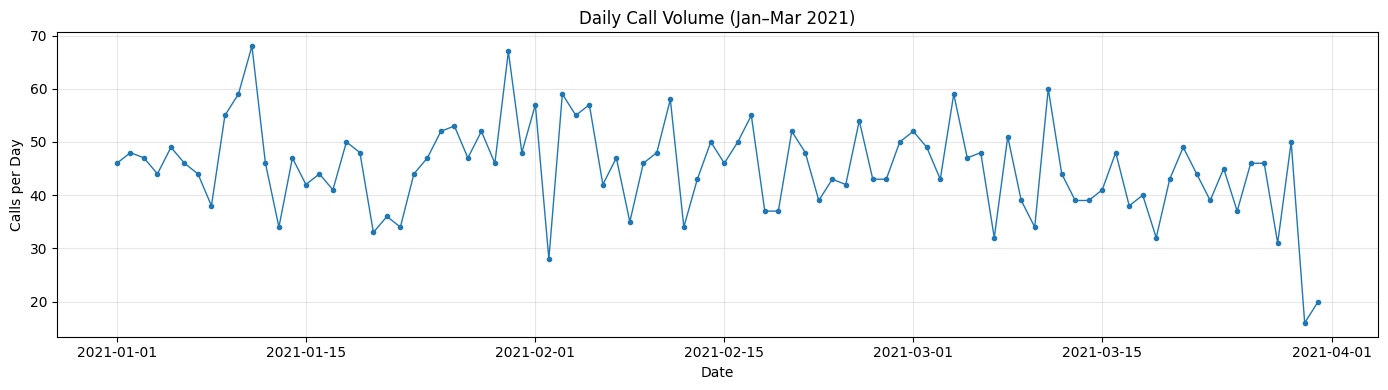

In [37]:
# Plot daily call volume over time
plt.figure(figsize=(14, 4))
plt.plot(calls_per_day['date'], calls_per_day['number_of_calls'], marker='o', markersize=3, linewidth=1)
plt.title('Daily Call Volume (Jan–Mar 2021)')
plt.xlabel('Date')
plt.ylabel('Calls per Day')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Insights:
- Our data does not seem to fit a poisson distribution, so what do we do? In real world scenarios we can stop and pivot to another or  can continue but with diligence(the same way we mentione that as data increases the variability increases hence transforming the poisson distrbution closer to normality but if we assume normality we need to take caution as well)

- However, for learning purposes we will proceed with the tests/ calculations 

#### **Calcluate the probabilities**

recall our objective: probability of attaining at least 100 calls per day.  With this at mind three core approached come about:

- **Probability Mass Functoin(PMF)**: **exactly** k=100 
- **Cumulative Density Function(CDF)**: **atmost** k values/ events k <= 100
- **1 - Cumulative Density Function(CDF)**: **atleast** k events k >= 100  **

In [38]:
k  = 100 # 

# attaining exactly 100 calls (PMF) => k=100: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 100 calls (CDF) => k<=100:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 100 calls (CDF) => k >= 100:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 100 outcomes is 0.000000 
Probabilty of getting atmost 100 outcomes is 1.000000 
Probabilty of getting atleast 100 outcomes is 0.000000 


In [39]:
k  = 50 # 

# attaining exactly 100 calls (PMF) => k=100: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 100 calls (CDF) => k<=100:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 100 calls (CDF) => k >= 100:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 50 outcomes is 0.043295 
Probabilty of getting atmost 50 outcomes is 0.794361 
Probabilty of getting atleast 50 outcomes is 0.205639 


In [40]:
k  = 20 # 

# attaining exactly 100 calls (PMF) => k=100: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 100 calls (CDF) => k<=100:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 100 calls (CDF) => k >= 100:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 20 outcomes is 0.000013 
Probabilty of getting atmost 20 outcomes is 0.000023 
Probabilty of getting atleast 20 outcomes is 0.999977 


As we lower the value of k below the arithmetic mean what do you notice? 
the probabiliies shift to less than 1 greater than zero

#### **Visualizing the distribution:**

In [60]:
# function to plot a histogram: 

def plotHist(data):
   
    lambda_hat = data.mean()

    # Plot histogram with whole 100 records
    counts, bins, patches = plt.hist(data , bins=5, alpha=0.7, 
                                    color='skyblue', edgecolor='black', 
                                    density=True, label='Actual data')
    # Generate points for the Poisson distribution line
    x = np.arange(data.min() - 2, data.max() + 3, 1) #To Create a SMOOTH LINE for the Theoretical Distribution
    poisson_values = stats.poisson.pmf(x, lambda_hat)

    # Plot Poisson distribution line
    plt.plot(x, poisson_values, 'ro-', linewidth=2, markersize=8, 
            label=f'Poisson distribution (λ={lambda_hat:.2f})', 
            markerfacecolor='red', markeredgecolor='darkred')

    # Add vertical line for the mean
    plt.axvline(lambda_hat, color='green', linestyle='--', 
                linewidth=2, label=f'Mean = {lambda_hat:.2f}')

    # Customize the plot
    plt.xlabel('Number of Calls per Day', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.title('Distribution of Daily Call Volume', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # Add value labels on the histogram bars
    for i, (bins, patches) in enumerate(zip(bins[:-1], patches)):
        height = patches.get_height()
        if height > 0:
            plt.text(bins + 0.5, height + 0.01, 
                    f'{data.iloc[i]}', 
                    ha='center', fontsize=10)

    # Add text box with statistics
    stats_text = f'Total days: {len(data)}\nMean (λ): {lambda_hat:.2f}\nVariance: {data.var():.2f}'
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

In [58]:
df_10 = calls_per_day['number_of_calls'].loc[:10] 
df_20 = calls_per_day['number_of_calls'].loc[:20] 
df_50 = calls_per_day['number_of_calls'].loc[:50] 
df_all = calls_per_day['number_of_calls']

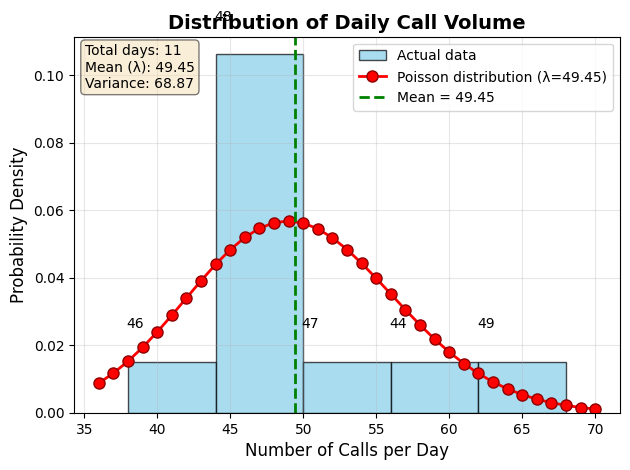

In [61]:
plotHist(df_10)

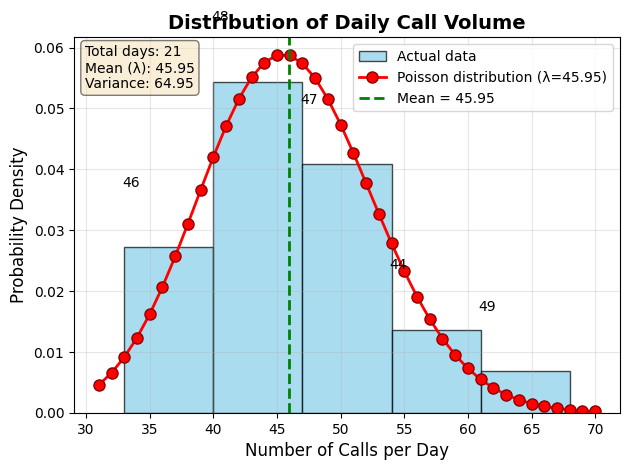

In [62]:
plotHist(df_20)

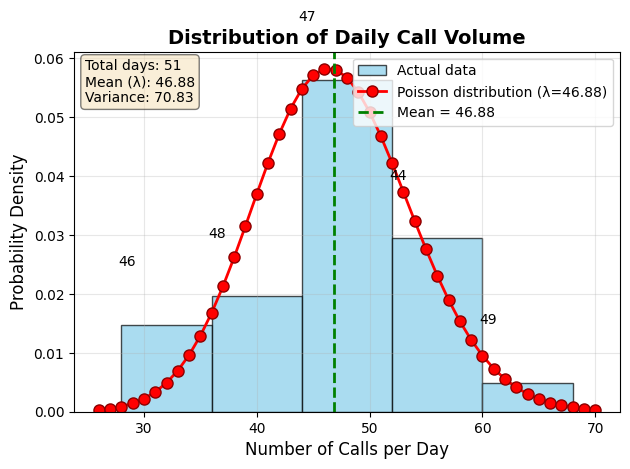

In [63]:
plotHist(df_50)

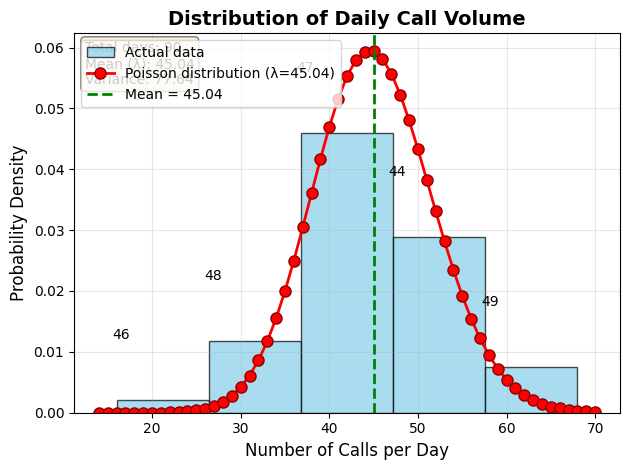

In [64]:
plotHist(df_all)

Text(0.5, 1.0, 'Q-Q Plot against Poisson')

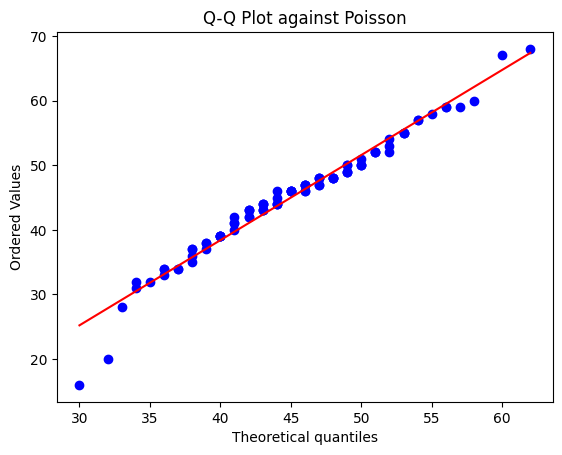

In [65]:
stats.probplot(calls_per_day['number_of_calls'], dist="poisson", sparams=(lambda_hat,), plot=plt)
plt.title('Q-Q Plot against Poisson')

NOTE:
In general there exist many distributions but we start of by asking what kind of data(discrete or continous) am I dealing with? Kindly note that binary data is as well discrete. 

If we are on the discrete side poisson,  binomial, -ve binomial, on the continuous side we have normal, log-normal and exponential. There exists more distributions but we start here.